In [1]:
import os
os.environ["MUJOCO_GL"] = "osmesa"
import mujoco
import mediapy as media

In [ ]:
xml = """

<mujoco model="inverted_pendulum">

    <!-- Ground -->
    <asset>
        <texture name="grid" type="2d" builtin="checker" rgb1=".1 .2 .3"
            rgb2=".2 .3 .4" width="300" height="300"/>
        <material name="grid" texture="grid" texrepeat="8 8" reflectance=".2"/>
    </asset>

    <worldbody>
        <!-- Insert Ground -->
        <geom size=".2 .2 .01" type="plane" material="grid"/>

        <!-- Insert Light -->
        <light pos="0 0 .6"/>

        <!-- Camera Position -->
        <camera name="closeup" pos="0 -.1 .07" xyaxes="1 0 0 0 1 2"/>

        <!-- Main Body -->
        <body name="cart" pos="0 0 1"> 
            <!-- Cart (Sliding in one axis only) -->
            <joint name="cart_slide" type="slide" axis="1 0 0"/> 
            <geom name="cart_geom" type="box" size="0.2 0.1 0.1" rgba="0 0 1 0.2"/>

            <!-- Arm -->
            <body name="pendulum" pos="0 0 0.1">
                <joint name="hinge" type="hinge" axis="0 1 0" pos="0 0 0"/>
                <geom name="pendulum_geom" type="capsule" fromto="0 0 0 0 0 0.8" size="0.05" rgba="0 1 0 0.2"/>
            </body>
        </body>
    </worldbody>
</mujoco>
"""

""

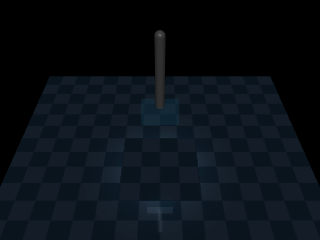

In [3]:
xml = """

<mujoco model="inverted_pendulum">
    <!-- Ground -->
    <asset>
        <texture name="grid" type="2d" builtin="checker" rgb1=".1 .2 .3"
        rgb2=".2 .3 .4" width="600" height="600"/>
        <material name="grid" texture="grid" texrepeat="8 8" reflectance=".2"/>
    </asset>

    <worldbody>
      <!-- Insert Ground -->
      <geom size="2 2 .01" type="plane" material="grid"/>

      <!-- Lighting -->
      <light pos="0 0 1"/>
      
      <body name="cart" pos="0 0 1"> 
        <!-- Cart -->
        <joint name="cart_slide" type="slide" axis="1 0 0"/>
        <geom name="cart_geom" type="box" size="0.2 0.1 0.1" rgba="0.2 0.6 0.8 0.2"/>

          <!-- Arm -->
          <body name="pendulum" pos="0 0 0.1">
            <joint name="hinge" type="hinge" axis="0 1 0" pos="0 0 0"/>
            <geom name="pendulum_geom" type="capsule" fromto="0 0 0 0 0 0.8" size="0.05"/>
          </body>
      </body>
    </worldbody>

</mujoco>

"""

model = mujoco.MjModel.from_xml_string(xml)
data = mujoco.MjData(model)

mujoco.mj_forward(model, data)
with mujoco.Renderer(model) as renderer:
  renderer.update_scene(data)

  media.show_image(renderer.render())

In [ ]:
xml = """
<mujoco model="inverted_pendulum">
    <compiler angle="degree" coordinate="local"/>
    <option gravity="0 0 -9.81" integrator="RK4" timestep="0.01"/>

    <default>
        <joint limited="false"/>
        <geom size="0.05" rgba="0.8 0.6 0.4 1"/>
    </default>

    <worldbody>
        <!-- Ground -->
        <geom name="ground" type="plane" size="10 10 0.1" rgba="0.2 0.3 0.4 1"/>

        <!-- Cart -->
        <body name="cart" pos="0 0 0.1">
            <joint name="slide_x" type="slide" axis="1 0 0"/>
            <geom name="cart_geom" type="box" size="0.2 0.1 0.05" rgba="0.2 0.6 0.8 1"/>
            <inertial pos="0 0 0" mass="1.1"/>

            <!-- Pendulum arm -->
            <body name="pendulum" pos="0 0 0.05">
                <joint name="hinge" type="hinge" axis="0 1 0" pos="0 0 0"/>
                <geom name="pendulum_geom" type="capsule" fromto="0 0 0 0 0 -0.8" size="0.03"/>
                <inertial pos="0 0 -0.4" mass="1.1"/>

                <!-- End mass -->
                <body name="end_mass" pos="0 0 -0.8">
                    <geom name="mass_geom" type="sphere" size="0.05" rgba="0.9 0.1 0.1 1"/>
                    <inertial mass="0.3" pos="0 0 0"/>
                </body>
            </body>
        </body>
    </worldbody>

    <actuator>
        <!-- Motor to drive the cart in x -->
        <motor name="cart_motor" joint="slide_x" ctrlrange="-10 10"/>
    </actuator>
</mujoco>

"""
model = mujoco.MjModel.from_xml_string(xml)
data = mujoco.MjData(model)

# Enable joint axes visualization
scene_option = mujoco.MjvOption()
scene_option.flags[mujoco.mjtVisFlag.mjVIS_JOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_FRAME] = True  # show body frames

# Use passive viewer but render with scene_option
with mujoco.viewer.launch_passive(model, data) as viewer:
    import time
    timestep = 0.01
    while viewer.is_running():
        mujoco.mj_step(model, data)
        # Update viewer scene manually using scene_option
        viewer.render_scene(scene_option=scene_option)
        time.sleep(timestep)

In [ ]:
import sympy as sp

# Define symbolic state variables
x, x_dot, theta, theta_dot = sp.symbols('x x_dot theta theta_dot')
F, m, M, l, g = sp.symbols('F m M l g')  # parameters

# Example: simple inverted pendulum dynamics (cart-pendulum)
# θ = theta, θ_dot = theta_dot, x = cart position, x_dot = cart velocity
# Using standard equations for a pendulum on a cart

cart_kin = 0.5*M*x_dot**2
pend_kin = 0.2*m*(x_dot**2 + (l*theta_dot)**2 + 2*x_dot*l*theta_dot*sp.cos(theta))

pot = m*g*l*sp.cos(theta)

L = cart_kin + pend_kin - pot

dL_dx = sp.diff(L, x)
dL_dx_dot = sp.diff(L, x_dot)
dL_dtheta = sp.diff(L, theta)
dL_dtheta_dot = sp.diff(L, theta_dot)

x_ddot = (F + g*m*sin(theta)*cos(theta) - l*m*theta_dot**2*sin(theta))/(M - m*cos(theta)**2 + m)
theta_ddot = (F*cos(theta) + g*(M + m)*sin(theta) - l*m*theta_dot**2*sin(theta)*cos(theta))/(l*(M - m*cos(theta)**2 + m))

Linearized A matrix at upright:
⎡0  1      0      0⎤
⎢                  ⎥
⎢         g⋅m      ⎥
⎢0  0     ───     0⎥
⎢          M       ⎥
⎢                  ⎥
⎢0  0      0      1⎥
⎢                  ⎥
⎢      g⋅(M + m)   ⎥
⎢0  0  ─────────  0⎥
⎣         M⋅l      ⎦
